<a href="https://colab.research.google.com/github/JX-bio/bioprocess-analysis/blob/main/ddPCR_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Upload your ddPCR CSV file
from google.colab import files
uploaded = files.upload()

Saving 20260514_Txx_MC_JX-titer_20260514_083910_549.csv to 20260514_Txx_MC_JX-titer_20260514_083910_549.csv


ddPCR Analysis Results

Sample: Crude Lysate
  vg/mL       = 1.227e+10
  Points used = 2
  Dilutions   = [ 1000. 10000.]
  Conc values = ['1243.1', '98.8']

Sample: Centrifuge Lysate
  vg/mL       = 2.204e+10
  Points used = 3
  Dilutions   = [  1000.  10000. 100000.]
  Conc values = ['1732.8', '197.6', '23.0']

Sample: Clarified Lysate
  vg/mL       = 1.903e+10
  Points used = 2
  Dilutions   = [ 1000. 10000.]
  Conc values = ['1720.1', '173.9']

Sample: Elution
  vg/mL       = 6.309e+12
  Points used = 3
  Dilutions   = [  100000.  1000000. 10000000.]
  Conc values = ['5738.5', '550.6', '59.6']

Sample: Flow Through
  vg/mL       = 2.541e+09
  Points used = 2
  Dilutions   = [ 1000. 10000.]
  Conc values = ['275.5', '18.7']

Results saved to ddpcr_results.csv
Plot saved to ddpcr_results.png


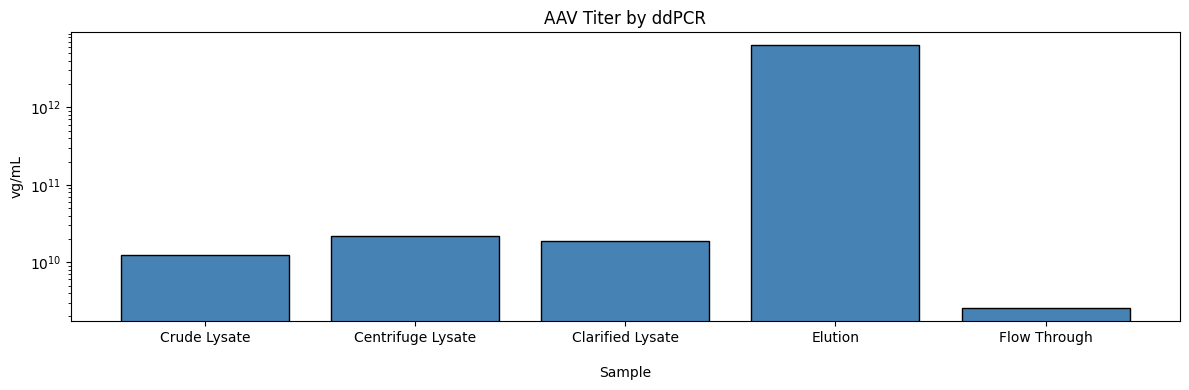

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# SETTINGS — only change this section for each new dataset
# ══════════════════════════════════════════════════════════════════════════════

INPUT_FILE = "20260514_Txx_MC_JX-titer_20260514_083910_549.csv"  # your CSV filename

PLOT_TITLE = "AAV Titer by ddPCR"   # plot title

# Sample order — arrange as desired
ORDER = ['#1', '#2', '#4', '#3', '#5']

# Sample rename — replace with your actual sample names
RENAME_MAP = {
    '#1': 'Crude Lysate',
    '#2': 'Centrifuge Lysate',
    '#4': 'Clarified Lysate',
    '#3': 'Elution',
    '#5': 'Flow Through',
}

# ── Settings below rarely need to change ──────────────────────────────────
CONC_MIN      = 10       # copies/uL minimum
CONC_MAX      = 6000     # copies/uL maximum
OP_DILUTION   = 11       # fixed operational dilution factor
LINEARITY_MIN = 0.3      # adjacent ratio lower bound
LINEARITY_MAX = 3.0      # adjacent ratio upper bound

# ══════════════════════════════════════════════════════════════════════════════


def load_data(filepath):
    df = pd.read_csv(filepath)
    df.columns = ['sample', 'dilution', 'input_vol', 'col4',
                  'target', 'conc_per_ul', 'vg_ml_manual', 'vg_ml_final']
    df['conc_numeric'] = pd.to_numeric(df['conc_per_ul'], errors='coerce')
    df['dilution']     = pd.to_numeric(df['dilution'],    errors='coerce')
    df['vg_ml_calc']   = df['conc_numeric'] * df['dilution'] * 1000 * OP_DILUTION
    return df


def analyze_sample(group):
    """Linear range selection: conc 10-6000, stop when 10-fold linearity breaks."""
    group = group.sort_values('dilution')
    valid = group[(group['conc_numeric'] >= CONC_MIN) &
                  (group['conc_numeric'] <= CONC_MAX)].copy()
    if valid.empty:
        return None

    vg_vals   = valid['vg_ml_calc'].values
    dilutions = valid['dilution'].values
    concs     = valid['conc_numeric'].values

    keep = [0]
    for i in range(1, len(vg_vals)):
        ratio = vg_vals[i] / vg_vals[i - 1]
        if LINEARITY_MIN <= ratio <= LINEARITY_MAX:
            keep.append(i)
        else:
            break

    return {
        'vg_ml':          np.mean(vg_vals[keep]),
        'n_points':       len(keep),
        'dilutions_used': dilutions[keep],
        'concs_used':     concs[keep],
    }


def run_analysis(filepath):
    df      = load_data(filepath)
    results = {}

    for sample, group in df.groupby('sample'):
        res = analyze_sample(group)
        if res:
            results[sample] = res

    # Reorder + rename
    results = {k: results[k] for k in ORDER if k in results}
    results = {RENAME_MAP.get(k, k): v for k, v in results.items()}

    # ── Print results ─────────────────────────────────────────────────────────
    print("=" * 60)
    print("ddPCR Analysis Results")
    print("=" * 60)
    for sample, res in results.items():
        print(f"\nSample: {sample}")
        print(f"  vg/mL       = {res['vg_ml']:.3e}")
        print(f"  Points used = {res['n_points']}")
        print(f"  Dilutions   = {res['dilutions_used']}")
        print(f"  Conc values = {[f'{c:.1f}' for c in res['concs_used']]}")

    # ── Export to CSV ─────────────────────────────────────────────────────────
    out = pd.DataFrame({
        'Sample':      list(results.keys()),
        'vg_mL':       [r['vg_ml']    for r in results.values()],
        'Points_used': [r['n_points'] for r in results.values()],
    })
    out.to_csv("ddpcr_results.csv", index=False)
    print("\nResults saved to ddpcr_results.csv")

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 4))
    samples = list(results.keys())
    vg_vals = [results[s]['vg_ml'] for s in samples]

    ax.bar(samples, vg_vals, color='steelblue', edgecolor='black')
    ax.set_yscale('log')
    ax.set_ylabel('vg/mL')
    ax.set_xlabel('Sample', labelpad=15)
    ax.set_title(PLOT_TITLE)
    plt.tight_layout()
    plt.savefig("ddpcr_results.png", dpi=150)
    print("Plot saved to ddpcr_results.png")
    plt.show()

    return results


if __name__ == "__main__":
    run_analysis(INPUT_FILE)
